# 02 — Inference (all models)
Old:
Runs all models sequentially on every pair in `lpips_eval_set.csv`.

**New**: 
Given a `manifest.csv` (or `audit_decisions.csv`) file, we generate a DataFrame containing pairs of same-location images with different conditions and run all models sequentially on every pair within the DataFrame. 


Each model's outputs land in a separate folder so `03_evaluate.ipynb` can compare them.
**Models:**
- **A** — SD 1.5 img2img (structural baseline)
- **B** — InstructPix2Pix (instruction baseline)
- **C** — ControlNet + Canny (no fine-tuning)
- **D** — ControlNet + Canny + LoRA (fine-tuned on Penn campus)

Toggle which models to run with the boolean flags in the Config cell.
Each section clears GPU memory before loading the next model.

In [25]:
import sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    !pip install -q uv
    !uv pip install --system diffusers==0.27.2 'transformers>=4.38.0,<5' 'huggingface-hub<0.26' accelerate controlnet-aux peft pillow-heif pandas opencv-python-headless
    from google.colab import drive
    drive.mount('/content/drive')

In [ ]:
# ── Config — edit these ──────────────────────────────────────────────────────
import os
if IN_COLAB:
    BASE        = '/content/drive/My Drive/CIS_5190_group_project'
    LORA_DIR    = f'{BASE}/checkpoints/lora'   # set to None to skip model D
    CONTROLNET_DIR = f'{BASE}/checkpoints/controlnet'
else:
    BASE        = '..'
    LORA_DIR    = f'{BASE}/checkpoints/lora'
    CONTROLNET_DIR = f'{BASE}/checkpoints/controlnet'


TA_VALIDATION_PATH = ""
CONTROLNET_SOURCE = CONTROLNET_DIR if os.path.exists(CONTROLNET_DIR) else 'lllyasviel/sd-controlnet-canny'
print(f'ControlNet source: {CONTROLNET_SOURCE}')

# Toggle which models to run
RUN_SD_BASELINE    = True
RUN_IP2P           = True
RUN_CONTROLNET     = True
RUN_CONTROLNET_LORA = True   # requires LORA_DIR to exist

# Inference hyperparams
SD_STRENGTH  = 0.55
# Old 7.5
GUIDANCE     = 12
NUM_STEPS    = 30
# Old 1.5
IP2P_IMG_GUIDANCE = 1.1
IP2P_STEPS   = 100
CANNY_LOW    = 100
CANNY_HIGH   = 200
# Old 1.0
COND_SCALE   = 0.8   # ControlNet conditioning scale

NEGATIVE = 'blurry, distorted, cartoon, painting, unrealistic, low quality'

ControlNet source: lllyasviel/sd-controlnet-canny


In [ ]:
# Construct eval_df from a TA validation folder.
# Expected layout:
#   TA_VALIDATION_PATH/
#     pair_001/
#       [location]_[time_of_day]_[weather].jpeg
#       [location]_[time_of_day]_[weather].jpeg
#     pair_002/
#       ...
#
# This produces the same columns as 02_inference.ipynb's eval_df without using
# manifest.csv or metadata.csv.

import pandas as pd
from pathlib import Path

TA_VALIDATION_PATH = Path(TA_VALIDATION_PATH)
if not TA_VALIDATION_PATH.exists():
    raise FileNotFoundError(f'TA_VALIDATION_PATH does not exist: {TA_VALIDATION_PATH}')

# Reuse the existing image loader below: it opens os.path.join(ALIGNED_DIR, row['src_anchor']).
ALIGNED_DIR = str(TA_VALIDATION_PATH)

IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.webp'}

def parse_ta_image_name(path: Path):
    parts = path.stem.split('_')
    if len(parts) < 3:
        raise ValueError(
            f'Expected filename schema [location]_[time_of_day]_[weather].jpeg, got: {path.name}'
        )
    location = '_'.join(parts[:-2]).lower().strip()
    time_of_day = parts[-2].lower().strip()
    weather = parts[-1].lower().strip()
    return location, time_of_day, weather

rows = []
pair_dirs = sorted(p for p in TA_VALIDATION_PATH.iterdir() if p.is_dir())
if not pair_dirs:
    raise ValueError(f'No pair subfolders found in {TA_VALIDATION_PATH}')

for pair_dir in pair_dirs:
    images = sorted(p for p in pair_dir.iterdir() if p.is_file() and p.suffix.lower() in IMAGE_EXTS)
    if len(images) != 2:
        raise ValueError(f'Expected exactly 2 images in {pair_dir}, found {len(images)}')

    src_path, tgt_path = images
    src_location, src_tod, src_weather = parse_ta_image_name(src_path)
    tgt_location, tgt_tod, tgt_weather = parse_ta_image_name(tgt_path)

    if src_location != tgt_location:
        raise ValueError(
            f'Pair location mismatch in {pair_dir}: {src_path.name} vs {tgt_path.name}'
        )

    src_rel = str(src_path.relative_to(TA_VALIDATION_PATH))
    tgt_rel = str(tgt_path.relative_to(TA_VALIDATION_PATH))
    rows.append({
        'src_name': src_rel,
        'location': src_location,
        'src_tod': src_tod,
        'src_weather': src_weather,
        'src_anchor': src_rel,
        'tgt_name': tgt_rel,
        'tgt_tod': tgt_tod,
        'tgt_weather': tgt_weather,
        'split': 'val',
    })

eval_df = pd.DataFrame(rows, columns=[
    'src_name', 'location', 'src_tod', 'src_weather', 'src_anchor',
    'tgt_name', 'tgt_tod', 'tgt_weather', 'split',
])
print(f'Built eval_df from {TA_VALIDATION_PATH}: {len(eval_df)} pairs')
eval_df.head()

,src_name,location,src_tod,src_weather,src_anchor,tgt_name,tgt_tod,tgt_weather,split
0,images/collegegreen_daytime_rainy_aligned_alig...,collegegreen,daytime,rainy,images/collegegreen_daytime_rainy_aligned_alig...,images/collegegreen_night_clear_aligned_aligne...,night,clear,val
1,images/harrison_daytime_clear_aligned_aligned.jpg,harrison,daytime,clear,images/harrison_daytime_clear_aligned_aligned.jpg,images/harrison_daytime_rainy_aligned_aligned.jpg,daytime,rainy,val
2,images/locust1_sunset_rainy_aligned_aligned.jpg,locust1,sunset,rainy,images/locust1_sunset_rainy_aligned_aligned.jpg,images/locust1_sunset_rainy_aligned_aligned.jpg,sunset,rainy,val
3,images/mt_daytime_rainy_aligned_aligned.jpg,mt,daytime,rainy,images/mt_daytime_rainy_aligned_aligned.jpg,images/mt_night_clear_aligned_aligned.jpg,night,clear,val
4,images/mt_daytime_rainy_aligned_aligned.jpg,mt,daytime,rainy,images/mt_daytime_rainy_aligned_aligned.jpg,images/mt_sunset_cloudy_aligned_aligned.jpg,sunset,cloudy,val


In [28]:
import gc, os
import cv2
import numpy as np
import pandas as pd
import torch
from PIL import Image

# eval_df = pd.read_csv(EVAL_CSV)
print(f'Eval set: {len(eval_df)} pairs')

def free_gpu():
    gc.collect()
    torch.cuda.empty_cache()

def load_anchor(row) -> Image.Image:
    return Image.open(os.path.join(ALIGNED_DIR, row['src_anchor'])).convert('RGB').resize((512, 512))

def prompt_for(row) -> str:
    loc = row['location'].replace('_', ' ').title()
    return (
        f'A photo of {loc} on the University of Pennsylvania campus '
        f'at {row["tgt_tod"].lower()}, {row["tgt_weather"].lower()} weather, '
        f'architectural photography, realistic lighting, high quality'
    )

def get_canny(img: Image.Image) -> Image.Image:
    arr = np.array(img.convert('L'))
    edges = cv2.Canny(arr, CANNY_LOW, CANNY_HIGH)
    return Image.fromarray(np.stack([edges]*3, axis=-1))

def run_inference(pipe_fn, out_dir: str, suffix: str):
    """pipe_fn(row, src_anchor) → PIL Image"""
    os.makedirs(out_dir, exist_ok=True)
    results = []
    for _, row in eval_df.iterrows():
        anchor = load_anchor(row)
        out_img = pipe_fn(row, anchor)
        stem = os.path.splitext(os.path.basename(row['tgt_name']))[0]
        fname = f'{stem}{suffix}'
        out_img.save(os.path.join(out_dir, fname))
        results.append({**row.to_dict(), 'generated_file': fname})
    pd.DataFrame(results).to_csv(os.path.join(out_dir, 'results.csv'), index=False)
    print(f'  Saved {len(results)} images → {out_dir}')

Eval set: 22 pairs


## A — SD 1.5 img2img (baseline)

In [29]:
if RUN_SD_BASELINE:
    from diffusers import AutoPipelineForImage2Image

    pipe_sd = AutoPipelineForImage2Image.from_pretrained(
        'stable-diffusion-v1-5/stable-diffusion-v1-5',
        torch_dtype=torch.float16, variant='fp16', use_safetensors=True,
    )
    pipe_sd.enable_model_cpu_offload()

    def sd_fn(row, anchor):
        return pipe_sd(
            prompt=prompt_for(row), image=anchor,
            strength=SD_STRENGTH, guidance_scale=GUIDANCE,
            num_inference_steps=NUM_STEPS,
        ).images[0]

    print('Running SD baseline...')
    run_inference(sd_fn, f'{BASE}/outputs/sd_baseline', '_sd_baseline.jpg')

    del pipe_sd; free_gpu()
    print('GPU cleared.')

/home/ubuntu/image-style-transfer/.venv/lib/python3.12/site-packages/huggingface_hub/file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Running SD baseline...


  0%|          | 0/16 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]

...

  0%|          | 0/16 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]

  Saved 22 images → ../outputs/sd_baseline
GPU cleared.


## B — InstructPix2Pix (baseline)

In [30]:
if RUN_IP2P:
    from diffusers import StableDiffusionInstructPix2PixPipeline

    pipe_ip2p = StableDiffusionInstructPix2PixPipeline.from_pretrained(
        'timbrooks/instruct-pix2pix',
        torch_dtype=torch.float16, safety_checker=None,
    )
    pipe_ip2p.enable_model_cpu_offload()

    def ip2p_fn(row, anchor):
        instruction = f"Change this photo to {row['tgt_tod'].lower()} with {row['tgt_weather'].lower()} weather"
        return pipe_ip2p(
            prompt=instruction, image=anchor,
            num_inference_steps=IP2P_STEPS,
            image_guidance_scale=IP2P_IMG_GUIDANCE,
            guidance_scale=GUIDANCE,
        ).images[0]

    print('Running InstructPix2Pix...')
    run_inference(ip2p_fn, f'{BASE}/outputs/instructpix2pix', '_ip2p.jpg')

    del pipe_ip2p; free_gpu()
    print('GPU cleared.')

/home/ubuntu/image-style-transfer/.venv/lib/python3.12/site-packages/huggingface_hub/file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Running InstructPix2Pix...


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

...

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  Saved 22 images → ../outputs/instructpix2pix
GPU cleared.


## C — ControlNet + Canny (no LoRA)

In [31]:
if RUN_CONTROLNET:
    from diffusers import StableDiffusionControlNetPipeline, ControlNetModel, UniPCMultistepScheduler

    controlnet = ControlNetModel.from_pretrained(
        CONTROLNET_SOURCE, torch_dtype=torch.float16
    )
    pipe_cn = StableDiffusionControlNetPipeline.from_pretrained(
        'stable-diffusion-v1-5/stable-diffusion-v1-5',
        controlnet=controlnet, torch_dtype=torch.float16, use_safetensors=True,
    )
    pipe_cn.scheduler = UniPCMultistepScheduler.from_config(pipe_cn.scheduler.config)
    pipe_cn.enable_model_cpu_offload()

    def cn_fn(row, anchor):
        return pipe_cn(
            prompt=prompt_for(row), negative_prompt=NEGATIVE,
            image=get_canny(anchor),
            num_inference_steps=NUM_STEPS, guidance_scale=GUIDANCE,
            controlnet_conditioning_scale=COND_SCALE,
        ).images[0]

    print(f'Running ControlNet from {CONTROLNET_SOURCE}...')
    run_inference(cn_fn, f'{BASE}/outputs/controlnet', '_controlnet.jpg')

    del pipe_cn, controlnet; free_gpu()
    print('GPU cleared.')

/home/ubuntu/image-style-transfer/.venv/lib/python3.12/site-packages/huggingface_hub/file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Running ControlNet from lllyasviel/sd-controlnet-canny...


  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

...

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  Saved 22 images → ../outputs/controlnet
GPU cleared.


## D — ControlNet + Canny + LoRA

In [32]:
lora_ready = RUN_CONTROLNET_LORA and LORA_DIR and os.path.exists(LORA_DIR)
if RUN_CONTROLNET_LORA and not lora_ready:
    print(f'Skipping model D — LORA_DIR not found: {LORA_DIR}')

if lora_ready:
    from diffusers import StableDiffusionControlNetPipeline, ControlNetModel, UniPCMultistepScheduler

    controlnet = ControlNetModel.from_pretrained(
        CONTROLNET_SOURCE, torch_dtype=torch.float16
    )
    pipe_cnl = StableDiffusionControlNetPipeline.from_pretrained(
        'stable-diffusion-v1-5/stable-diffusion-v1-5',
        controlnet=controlnet, torch_dtype=torch.float16, use_safetensors=True,
    )
    pipe_cnl.scheduler = UniPCMultistepScheduler.from_config(pipe_cnl.scheduler.config)
    pipe_cnl.load_lora_weights(LORA_DIR)
    pipe_cnl.enable_model_cpu_offload()
    print(f'LoRA loaded from {LORA_DIR}')

    def cnl_fn(row, anchor):
        return pipe_cnl(
            prompt=prompt_for(row), negative_prompt=NEGATIVE,
            image=get_canny(anchor),
            num_inference_steps=NUM_STEPS, guidance_scale=GUIDANCE,
            controlnet_conditioning_scale=COND_SCALE,
        ).images[0]

    print('Running ControlNet + LoRA...')
    run_inference(cnl_fn, f'{BASE}/outputs/controlnet_lora', '_controlnet_lora.jpg')

    del pipe_cnl, controlnet; free_gpu()
    print('GPU cleared.')

/home/ubuntu/image-style-transfer/.venv/lib/python3.12/site-packages/huggingface_hub/file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


/home/ubuntu/image-style-transfer/.venv/lib/python3.12/site-packages/huggingface_hub/file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

LoRA loaded from ../checkpoints/lora
Running ControlNet + LoRA...


  0%|          | 0/30 [00:00<?, ?it/s]

...

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  Saved 22 images → ../outputs/controlnet_lora
GPU cleared.


## Side-by-side preview
Shows one eval pair across all models that finished.

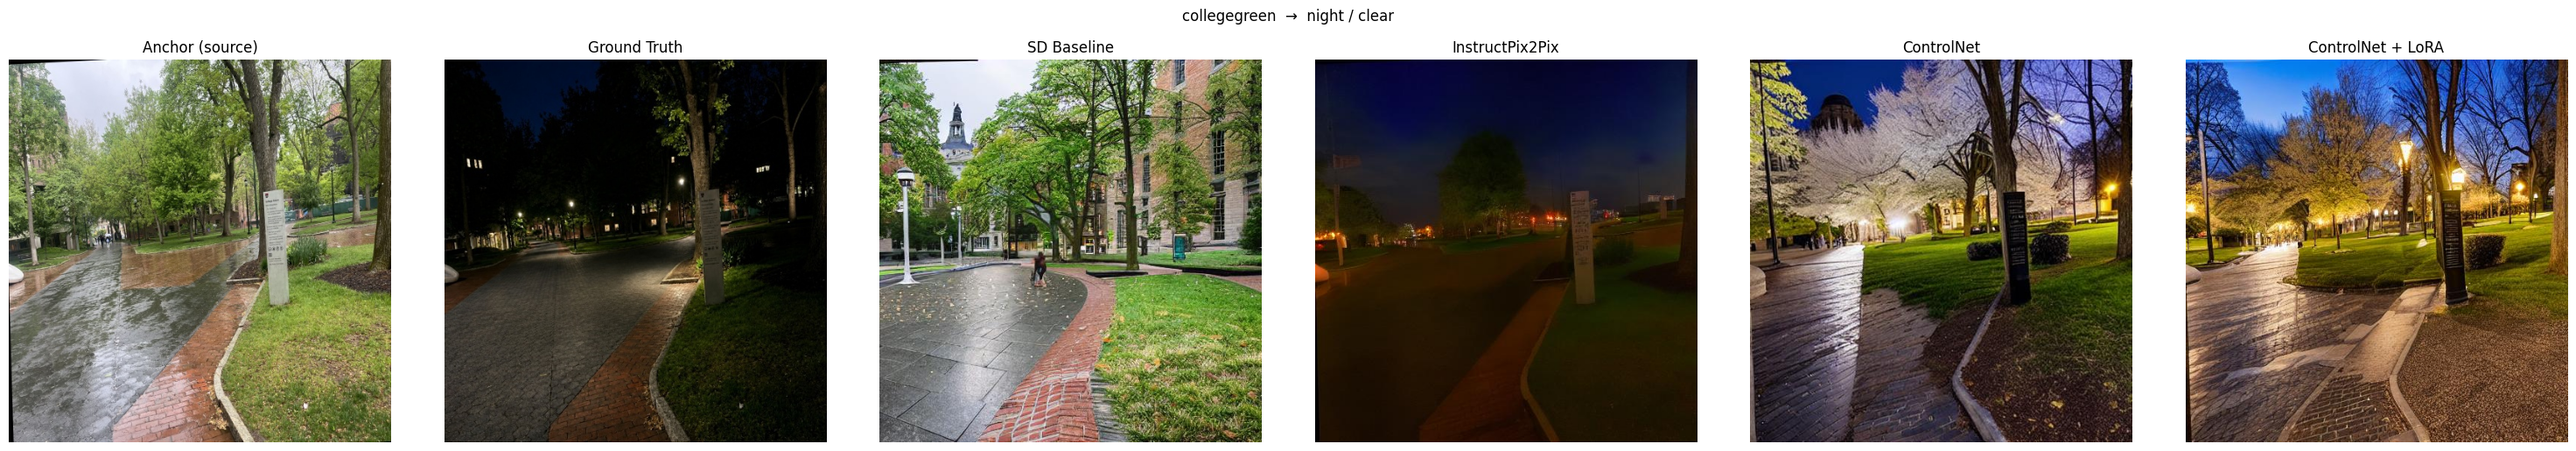

In [34]:
import matplotlib.pyplot as plt

MODEL_OUTPUTS = {
    'SD Baseline':        (f'{BASE}/outputs/sd_baseline',      '_sd_baseline.jpg'),
    'InstructPix2Pix':    (f'{BASE}/outputs/instructpix2pix',  '_ip2p.jpg'),
    'ControlNet':         (f'{BASE}/outputs/controlnet',       '_controlnet.jpg'),
    'ControlNet + LoRA':  (f'{BASE}/outputs/controlnet_lora',  '_controlnet_lora.jpg'),
}

row = eval_df.iloc[0]
stem = os.path.splitext(os.path.basename(row['tgt_name']))[0]
anchor = Image.open(os.path.join(ALIGNED_DIR, row['src_anchor']))
gt     = Image.open(os.path.join(ALIGNED_DIR, row['tgt_name']))

panels = [('Anchor (source)', anchor), ('Ground Truth', gt)]
for name, (out_dir, suffix) in MODEL_OUTPUTS.items():
    p = os.path.join(out_dir, stem + suffix)
    if os.path.exists(p):
        panels.append((name, Image.open(p)))

fig, axes = plt.subplots(1, len(panels), figsize=(5 * len(panels), 5))
for ax, (title, img) in zip(axes, panels):
    ax.imshow(img); ax.set_title(title); ax.axis('off')
plt.suptitle(f"{row['location']}  →  {row['tgt_tod']} / {row['tgt_weather']}", y=1.02)
plt.tight_layout()
plt.show()